In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [2]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");
using PyCall, JLD2
np = pyimport("numpy");

In [13]:
log_dir = "./logs/"
loaded_logs = load(log_dir * "dispersion-logs.jld2");
logsv = loaded_logs["logsv"];

In [14]:
dispersionv = Float64[]
dispersionv_band2 = Float64[]
kxv = Float64[]
kyv = Float64[]
kzv = Float64[] # vectors corresponding to the kx, ky, and kz (in lattice coordinates) for each sampled point 

for (id, log) in enumerate(logsv)
    (id % 2000) == 0 && (println("id: $id"); flush(stdout))
    dispersion_str = logs_to_dispersion(log, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end] # the first 5 elements correspond to b-zone coordinates
    push!(dispersionv, vec(dispersion)...) # All frequency points 
    kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];
    push!(kxv, kpts[:, 1]...)
    push!(kyv, kpts[:, 2]...)
    push!(kzv, kpts[:, 3]...)
    push!(dispersionv_band2, dispersion[:, 2]...) # Frequency points corresponding to second band
end

id: 2000
id: 4000
id: 6000
id: 8000
id: 10000


### We print one of the log files to make sure parameters are valid (e.g. the permittivities of the cylinders and the vacuum region and the radii of the cylinders). 

In [15]:
println(logsv[1])

command-line param: epsin=11
command-line param: r1=0.18
command-line param: r2=0.18
command-line param: ky=-0.49
command-line param: kz=-0.49
init-params: initializing eigensolver data
Computing 5 bands with 1.000000e-07 tolerance.
Working in 3 dimensions.
Grid size is 32 x 32 x 32.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.25,0.25,0.25)
          radius 0.18, height 0.866025, axis (0.57735, 0.57735, 0.57735)
          epsilon = 11, mu = 1
     cylinder, center = (-0.25,-0.25,0.25)
          radius 0.18, height 0.866025, axis (-0.57735, -0.57735, 0.57735)
          epsilon = 11, mu = 1
     cylinder, center = (0.25,-0.25,-0.25)
          radius 0.18, height 0.866025, axis (0.57735, -0.57735, -0.57735)
          epsilon = 11, mu = 1
     cylinder, ce

In [16]:
dos, energies = np.histogram(dispersionv, bins=10000) # Bin the values 
window_size = 20
dos_smoothed_1 = np.convolve(dos, np.ones(window_size)/window_size, mode="same"); # Moving average over a length given by window_size. We try two different window sizes. 
window_size = 200
dos_smoothed_2 = np.convolve(dos, np.ones(window_size)/window_size, mode="same");

In [17]:
log_dir_zoom = "../fig_dos_zoom/logs/"
loaded_logs_zoom = load(log_dir_zoom * "dispersion-logs.jld2");
logsv_zoom = loaded_logs_zoom["logsv"];

In [18]:
dispersionv_zoom = Float64[]
dispersionv_band2_zoom = Float64[]
kxv_zoom = Float64[]
kyv_zoom = Float64[]
kzv_zoom = Float64[]

for (id, log) in enumerate(logsv_zoom)
    (id % 2000) == 0 && (println("id: $id"); flush(stdout))
    dispersion_str = logs_to_dispersion(log, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
    push!(dispersionv_zoom, vec(dispersion)...)
    kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];
    push!(kxv_zoom, kpts[:, 1]...)
    push!(kyv_zoom, kpts[:, 2]...)
    push!(kzv_zoom, kpts[:, 3]...)
    push!(dispersionv_band2_zoom, dispersion[:, 2]...)
end

id: 2000
id: 4000
id: 6000
id: 8000
id: 10000


In [19]:
dos_zoom, energies_zoom = np.histogram(dispersionv_zoom, bins=10000);

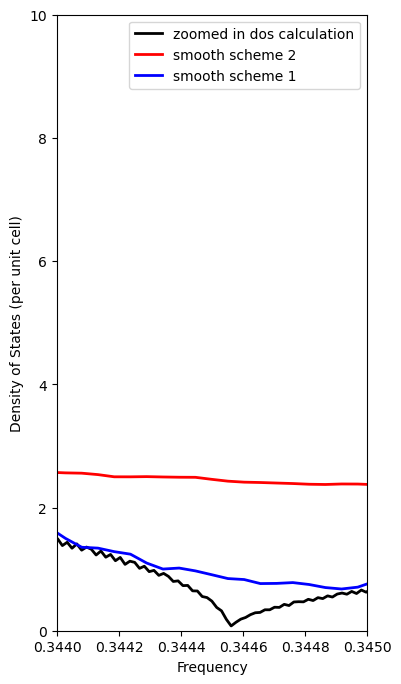

In [20]:
figure(figsize=(4, 8))
linewidth=2
num_bands = 5
zoom_factor = 10^3 # The zoomed in plots are over a region that is 1/1000'th of the volume of the whole Brillouin zone, so we must account for this. 
plot(energies_zoom[1:end-1], dos_zoom/length(dispersionv_zoom)/diff(energies_zoom)[1]/zoom_factor*num_bands, label="zoomed in dos calculation", color="black", linewidth=linewidth)
plot(energies[1:end-1], dos_smoothed_2/length(dispersionv)/diff(energies)[1]*num_bands, label="smooth scheme 2", color="red", linewidth=linewidth) # units of per unit cell per frequency
plot(energies[1:end-1], dos_smoothed_1/length(dispersionv)/diff(energies)[1]*num_bands, label="smooth scheme 1", color="blue", linewidth=linewidth)
legend();
ylim(0, 10)
xlim(0.344, 0.345)
xlabel("Frequency")
ylabel("Density of States (per unit cell)");

### Here we try to combine the dos plots in a sensible way

In [21]:
# Scheme: First combine the moving averaged coarse bzone samplings. If away from the degeneracy, use a large window and if near the degeneracy use a small window. 
dos_smoothed = [0.34 < energies[n] < 0.35 ? dos_smoothed_1[n] : dos_smoothed_2[n] for n in 1:length(energies)-1] ;

In [22]:
nk = length(dispersionv)/5 # number of k points is length of dispersion divided by the number of bands
nk_zoom = length(dispersionv)/5

near_degeneracy_idxs = findall(x-> 0.344 < x < 0.345, energies_zoom[1:end-1]);
away_from_degeneracy_idxs_1 = findall(x-> 0.344 > x , energies[1:end-1]);
away_from_degeneracy_idxs_2 = findall(x-> 0.345 < x , energies[1:end-1]);
normalized_dos = dos_smoothed/nk/diff(energies)[1]
normalized_dos_zoom = dos_zoom/nk_zoom/diff(energies_zoom)[1]/zoom_factor;

In [23]:
combined_energies = [energies[away_from_degeneracy_idxs_1]..., energies_zoom[near_degeneracy_idxs]..., energies[away_from_degeneracy_idxs_2]...];
combined_dos = [normalized_dos[away_from_degeneracy_idxs_1]..., normalized_dos_zoom[near_degeneracy_idxs]..., normalized_dos[away_from_degeneracy_idxs_2]...];

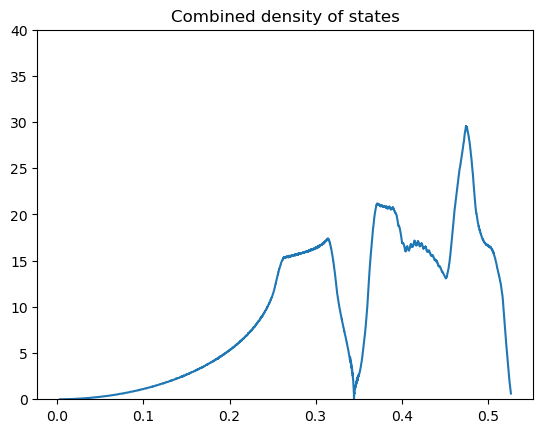

In [24]:
plot(combined_energies, combined_dos)
ylim(0, 40)
title("Combined density of states");

In [47]:
### Check that integrating the dos gives a reasonable answer: 
@assert isapprox(sum(combined_dos[1:end-1] .* diff(combined_energies))/5*100, 100, atol=0.5)

In [53]:
jldopen("dos.jld2", "w") do fid
    fid["epsilon"] = 11 # We save epsilon since we did a bunch of different versions of this. 
    fid["energies"] = combined_energies
    fid["dos"] = combined_dos
end;

### Afterwards, we noticed that there's a slight error. Namely, that the interpolation code in the ctl files counts both $k_x=-0.5$ and $k_x=0.5$, which are equivalent. Below, we check how much of a difference this makes

In [4]:
dispersionv = Float64[]
dispersionv_corrected = Float64[]
for (id, log) in enumerate(logsv)
    (id % 2000) == 0 && (println("id: $id"); flush(stdout))
    dispersion_str = logs_to_dispersion(log, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end] # the first 5 elements correspond to b-zone coordinates
    dispersion_corrected = readdlm(IOBuffer(dispersion_str), ',')[1:end-1, 6:end] # the first 5 elements correspond to b-zone coordinates
    push!(dispersionv, vec(dispersion)...) # All frequency points 
    push!(dispersionv_corrected, vec(dispersion_corrected)...) # All frequency points 
end

id: 2000
id: 4000
id: 6000
id: 8000
id: 10000


In [25]:
dos, energies = np.histogram(dispersionv, bins=10000)
dos_corrected, energies_corrected = np.histogram(dispersionv_corrected, bins=10000)
window_size = 200
dos_smoothed_2 = np.convolve(dos, np.ones(window_size)/window_size, mode="same");
dos_smoothed_2_corrected = np.convolve(dos_corrected, np.ones(window_size)/window_size, mode="same");

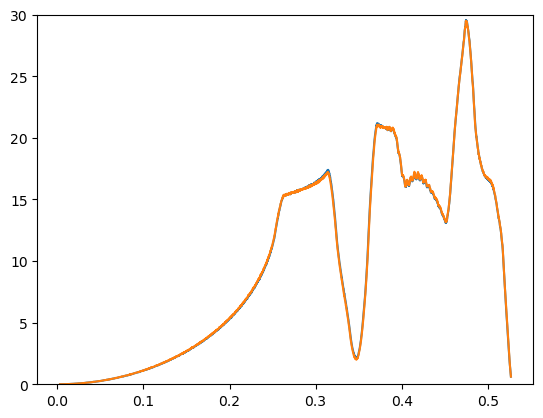

In [27]:
plot(energies[1:end-1], 5*dos_smoothed_2/length(dispersionv)/diff(energies)[1])
plot(energies_corrected[1:end-1], 5*dos_smoothed_2_corrected/diff(energies_corrected)[1]/length(dispersionv_corrected))
ylim(0, 30);